# PINNs Setup for Calderon Inverse Problem

In [6]:
# filename: codebase/pinn_framework.py
import torch
import torch.nn as nn
import numpy as np
from fdm_forward_solver import FDMForwardSolver
from tqdm import trange
import matplotlib.pyplot as plt

import os



## Simplified code

In [122]:
# def init_weights(m):
#     """
#     Applies Xavier uniform initialization to linear layers.

#     Args:
#         m (nn.Module): The module to initialize.
#     """
#     if isinstance(m, nn.Linear):
#         nn.init.xavier_uniform_(m.weight)
#         if m.bias is not None:
#             nn.init.zeros_(m.bias)


class FourierFeatureEncoder:
    """
    Implements Fourier Feature Encoding for spatial coordinates.
    Maps input coordinates to a higher-dimensional space to help NNs
    learn high-frequency functions.
    """
    def __init__(self, input_dims, mapping_size, scale, device):
        """
        Initializes the Fourier Feature Encoder.

        Args:
            input_dims (int): The number of input dimensions (e.g., 2 for (x, y)).
            mapping_size (int): The number of Fourier features (M).
            scale (float): The standard deviation for the random Gaussian matrix B.
            device (torch.device): The device to store the B matrix on.
        """
        self.input_dims = input_dims
        self.mapping_size = mapping_size
        self.scale = scale
        self.device = device
        # B matrix is non-trainable
        self.B = torch.randn((mapping_size, input_dims), device=self.device) * self.scale
        self.B.requires_grad = False

    def encode(self, x):
        """
        Encodes the input coordinates.

        Args:
            x (torch.Tensor): Input tensor of shape [batch_size, input_dims].

        Returns:
            torch.Tensor: Encoded tensor of shape [batch_size, 2 * mapping_size].
        """
        x_proj = (2. * np.pi * x) @ self.B.T
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)


class ConductivityNetwork(nn.Module):
    """
    Neural network to approximate the conductivity gamma(x, y).
    Input: Fourier-encoded spatial coordinates.
    Output: Scalar conductivity value.
    """
    def __init__(self, ffe_dims, layers=4, neurons=64):
        """
        Initializes the Conductivity Network.

        Args:
            ffe_dims (int): The dimension of the Fourier feature encoded input.
            layers (int): The number of hidden layers.
            neurons (int): The number of neurons per hidden layer.
        """
        super().__init__()
        
        net_layers = []
        input_dim = ffe_dims
        for _ in range(layers):
            net_layers.append(nn.Linear(input_dim, neurons))
            net_layers.append(nn.SiLU())
            input_dim = neurons
        
        net_layers.append(nn.Linear(neurons, 1))
        net_layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*net_layers)
        
        self.min_gamma = 0.5
        self.max_gamma = 2.5
        self.FLAG = False

    def forward(self, x_ffe):
        """
        Forward pass for the conductivity network.

        Args:
            x_ffe (torch.Tensor): The Fourier-encoded input tensor.

        Returns:
            torch.Tensor: The predicted conductivity, scaled to [0.5, 2.5].
        """
        raw_output = self.network(x_ffe)

        if self.FLAG==False:
            print('forward pass through gamma NN !')
            self.FLAG=True
            
        return self.min_gamma + (self.max_gamma - self.min_gamma) * raw_output


class PotentialNetwork(nn.Module):
    """
    Neural network to approximate the potential u_k(x, y).
    Input: Concatenation of Fourier-encoded spatial coordinates and a
           one-hot encoding for the boundary condition index k.
    Output: Scalar potential value.
    """
    def __init__(self, ffe_dims, num_bcs, layers=6, neurons=128):
        """
        Initializes the Potential Network.

        Args:
            ffe_dims (int): The dimension of the Fourier feature encoded input.
            num_bcs (int): The number of boundary conditions (K).
            layers (int): The number of hidden layers.
            neurons (int): The number of neurons per hidden layer.
        """
        super().__init__()
        
        input_dim = ffe_dims + num_bcs
        
        net_layers = []
        for _ in range(layers):
            net_layers.append(nn.Linear(input_dim, neurons))
            net_layers.append(nn.SiLU())
            input_dim = neurons
            
        net_layers.append(nn.Linear(neurons, 1))
        
        self.network = nn.Sequential(*net_layers)

    def forward(self, x_ffe, c_k):
        """
        Forward pass for the potential network.

        Args:
            x_ffe (torch.Tensor): The Fourier-encoded coordinate tensor.
            c_k (torch.Tensor): The one-hot encoded boundary condition tensor.

        Returns:
            torch.Tensor: The predicted potential u_k.
        """
        net_input = torch.cat([x_ffe, c_k], dim=1)

        output = self.network(net_input)
        return output


class CalderonPINN:
    """
    Encapsulates the PINN framework for Calderon's inverse problem.
    Manages networks, loss computations, and automatic differentiation.
    """
    def __init__(self, ffe_encoder, gamma_net, u_net, num_bcs, device):
        """
        Initializes the CalderonPINN manager.

        Args:
            ffe_encoder (FourierFeatureEncoder): The FFE instance.
            gamma_net (ConductivityNetwork): The conductivity network instance.
            u_net (PotentialNetwork): The potential network instance.
            num_bcs (int): The number of boundary conditions (K).
            device (torch.device): The device for computations.
        """
        self.ffe_encoder = ffe_encoder
        self.gamma_net = gamma_net
        self.u_net = u_net
        self.num_bcs = num_bcs
        self.device = device

    def _to_one_hot(self, k_indices, num_classes):
        """Converts integer indices to one-hot vectors."""
        one_hot = torch.zeros(k_indices.size(0), num_classes, device=self.device)
        one_hot.scatter_(1, k_indices.unsqueeze(1), 1)
        return one_hot

    def compute_pde_residual(self, xy_colloc, k_indices):
        """Computes the PDE residual: nabla . (gamma * nabla u)."""
        xy_colloc.requires_grad_(True)
        
        xy_ffe = self.ffe_encoder.encode(xy_colloc)
        gamma = self.gamma_net(xy_ffe)
        
        k_one_hot = self._to_one_hot(k_indices, self.num_bcs)
        u = self.u_net(xy_ffe, k_one_hot)
        
        grad_u = torch.autograd.grad(u, xy_colloc, torch.ones_like(u), create_graph=True)[0]
        du_dx = grad_u[:, 0:1]
        du_dy = grad_u[:, 1:2]
        
        flux_x = gamma * du_dx
        flux_y = gamma * du_dy
        
        div_flux_x = torch.autograd.grad(flux_x, xy_colloc, torch.ones_like(flux_x), create_graph=True)[0][:, 0:1]
        div_flux_y = torch.autograd.grad(flux_y, xy_colloc, torch.ones_like(flux_y), create_graph=True)[0][:, 1:2]
            
        return div_flux_x + div_flux_y

    # def compute_tv_loss(self, xy_colloc):
    #     """Computes the Total Variation regularization loss for gamma."""
    #     xy_colloc.requires_grad_(True)
        
    #     xy_ffe = self.ffe_encoder.encode(xy_colloc)
    #     gamma = self.gamma_net(xy_ffe)
        
    #     grad_gamma = torch.autograd.grad(gamma, xy_colloc, torch.ones_like(gamma), create_graph=True)[0]
        
    #     tv_loss = torch.sqrt(torch.sum(grad_gamma**2, dim=1) + 1e-8)
    #     return tv_loss.mean()

    def compute_data_predictions(self, xy_bnd, k_indices, normals):
        """Predicts potential u and normal current J on the boundary."""
        xy_bnd.requires_grad_(True)
        
        xy_ffe = self.ffe_encoder.encode(xy_bnd)
        gamma_pred = self.gamma_net(xy_ffe)
        
        k_one_hot = self._to_one_hot(k_indices, self.num_bcs)
       # print('k_one_hot', k_one_hot)
        u_pred = self.u_net(xy_ffe, k_one_hot)
        
        grad_u = torch.autograd.grad(u_pred, xy_bnd, torch.ones_like(u_pred), create_graph=True)[0]
        du_dn_pred = torch.sum(grad_u * normals, dim=1, keepdim=True)
        
        J_pred = gamma_pred * du_dn_pred
        
        return u_pred, J_pred
    

    def compute_full_loss(self, pde_batch, bnd_batch, weights):
        """
        Computes the total composite loss for a given batch of data.

        Args:
            pde_batch (tuple): Batch of collocation points and indices.
            bnd_batch (tuple): Batch of boundary data.
            weights (dict): Dictionary of weights for each loss component.

        Returns:
            tuple: A tuple containing the total loss tensor and a dictionary
                   of individual loss values for logging.
        """
        xy_colloc, k_colloc = pde_batch
        xy_bnd, k_bnd, normals_bnd, f_bnd, J_bnd = bnd_batch
        
        # 1. PDE Loss
        pde_residual = self.compute_pde_residual(xy_colloc, k_colloc)
        loss_pde = torch.mean(pde_residual**2)
        
        # # 2. TV Loss
        # loss_tv = self.compute_tv_loss(xy_colloc)
        
        # 3. Data Loss
        u_pred, J_pred = self.compute_data_predictions(xy_bnd, k_bnd, normals_bnd)
        loss_bc = torch.mean((u_pred - f_bnd)**2)
        loss_nd = torch.mean((J_pred - J_bnd)**2)
        loss_data = loss_bc + loss_nd
        
        # 4. Total Loss
        total_loss = (weights['pde'] * loss_pde +
                      weights['data'] * loss_data) #+
                      #weights['tv'] * loss_tv)
                      
        loss_dict = {
            'total': total_loss.detach().item(),
            'pde': loss_pde.detach().item(),
            'data': loss_data.detach().item(),
            'bc': loss_bc.detach().item(),
            'neumann': loss_nd.detach().item(),
            # 'tv': loss_tv.detach().item()
        }
        
        return total_loss, loss_dict
    
    def compute_forced_gamma_true_loss(self, pde_batch, bnd_batch, gamma_true_fn, weights):
        """
        Computes the loss when gamma is forced to match the true conductivity field.
        This is a sanity check for the 'direct problem'.

        Args:
            pde_batch (tuple): (xy_colloc, k_colloc) collocation points and BC indices.
            bnd_batch (tuple): (xy_bnd, k_bnd, normals_bnd, f_bnd, J_bnd).
            gamma_true_fn (callable): Function mapping (x,y) -> true conductivity values.
                                    Should accept tensor of shape [N,2] and return [N,1].
            weights (dict): Weights for PDE and data losses.

        Returns:
            tuple: (total_loss, loss_dict)
        """
        xy_colloc, k_colloc = pde_batch
        xy_bnd, k_bnd, normals_bnd, f_bnd, J_bnd = bnd_batch

        # --- 1. Compute true gamma at collocation points and boundary ---
        gamma_true_colloc = gamma_true_fn(xy_colloc)
        gamma_true_bnd = gamma_true_fn(xy_bnd)

        # --- 2. PDE residual with gamma_true ---
        xy_colloc.requires_grad_(True)
        xy_ffe = self.ffe_encoder.encode(xy_colloc)

        k_one_hot = self._to_one_hot(k_colloc, self.num_bcs)
        u_pred = self.u_net(xy_ffe, k_one_hot)

        grad_u = torch.autograd.grad(u_pred, xy_colloc, torch.ones_like(u_pred), create_graph=True)[0]
        du_dx, du_dy = grad_u[:, 0:1], grad_u[:, 1:2]

        flux_x = gamma_true_colloc * du_dx
        flux_y = gamma_true_colloc * du_dy

        div_flux_x = torch.autograd.grad(flux_x, xy_colloc, torch.ones_like(flux_x), create_graph=True)[0][:, 0:1]
        div_flux_y = torch.autograd.grad(flux_y, xy_colloc, torch.ones_like(flux_y), create_graph=True)[0][:, 1:2]

        loss_pde = torch.mean((div_flux_x + div_flux_y)**2)

        # --- 3. Data consistency with boundary ---
        xy_bnd.requires_grad_(True)
        xy_bnd_ffe = self.ffe_encoder.encode(xy_bnd)

        k_one_hot_bnd = self._to_one_hot(k_bnd, self.num_bcs)
        u_pred_bnd = self.u_net(xy_bnd_ffe, k_one_hot_bnd)

        grad_u_bnd = torch.autograd.grad(u_pred_bnd, xy_bnd, torch.ones_like(u_pred_bnd), create_graph=True)[0]
        du_dn_pred = torch.sum(grad_u_bnd * normals_bnd, dim=1, keepdim=True)

        J_pred = gamma_true_bnd * du_dn_pred

        loss_bc = torch.mean((u_pred_bnd - f_bnd)**2)
        loss_nd = torch.mean((J_pred - J_bnd)**2)
        loss_data = loss_bc + loss_nd

        # --- 4. Total loss ---
        total_loss = (weights['pde'] * loss_pde +
                    weights['data'] * loss_data)

        loss_dict = {
            'total': total_loss.detach().item(),
            'pde': loss_pde.detach().item(),
            'data': loss_data.detach().item(),
            'bc': loss_bc.detach().item(),
            'neumann': loss_nd.detach().item()
        }

        return total_loss, loss_dict

# def gamma_true_fn(xy):
#     x, y = xy[:, 0:1], xy[:, 1:2]
#     center_x, center_y, radius = 0.5, 0.5, 0.2
#     mask = ((x - center_x)**2 + (y - center_y)**2) < radius**2
#     gamma = torch.ones_like(x)
#     gamma[mask] = 2.0
#     return gamma


In [123]:
import numpy as np
import torch
from scipy.interpolate import RegularGridInterpolator

def load_gamma_interpolator(gamma):
    """
    Loads gamma(x,y) from .npz and returns an interpolator callable.
    
    Args:
        npz_path (str): Path to .npz file containing 'gamma'.
        
    Returns:
        callable: Function mapping torch.Tensor [N,2] -> torch.Tensor [N,1].
    """
    # data = np.load(npz_path)
    # gamma = data["gamma"]   # shape (N, N)

    N = gamma.shape[0]
    
    # Grid coordinates (assuming [0,1] domain as in get_gamma_gaussian)
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    
    # Build SciPy interpolator
    interp = RegularGridInterpolator((x, y), gamma, bounds_error=False, fill_value=None)
    
    def gamma_true_fn(xy_torch):
        xy_np = xy_torch.detach().cpu().numpy()   # shape [N,2]
        gamma_vals = interp(xy_np)                # shape [N]
        return torch.tensor(gamma_vals, dtype=xy_torch.dtype, device=xy_torch.device).unsqueeze(1)
    
    return gamma_true_fn


In [124]:
if __name__ == '__main__':
    # This block is for verification and will not be executed in the main pipeline
    print("--- PINN Framework Module ---")
    print("This script defines the core components for the Calderon PINN.")
    
    # Example instantiation
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

    print("Using device: " + str(device))

    # Hyperparameters
    FFE_DIMS = 2
    FFE_MAPPING_SIZE = 256
    FFE_SCALE = 10.0
    NUM_BCS = 32

    # 1. FFE
    ffe_encoder = FourierFeatureEncoder(FFE_DIMS, FFE_MAPPING_SIZE, FFE_SCALE, device)
    print("FourierFeatureEncoder instantiated.")

    # 2. Networks
    gamma_net = ConductivityNetwork(ffe_dims=FFE_MAPPING_SIZE * 2).to(device)
    # gamma_net.apply(init_weights)
    u_net = PotentialNetwork(ffe_dims=FFE_MAPPING_SIZE * 2, num_bcs=NUM_BCS).to(device)
    # u_net.apply(init_weights)
    print("ConductivityNetwork and PotentialNetwork instantiated and moved to device.")

    # 3. PINN Manager
    pinn_manager = CalderonPINN(ffe_encoder, gamma_net, u_net, NUM_BCS, device)
    print("CalderonPINN manager instantiated.")
    
    # Test with dummy data
    N_pde = 10
    N_b = 5
    xy_colloc_test = torch.rand(N_pde, 2, device=device)
    k_colloc_test = torch.randint(0, NUM_BCS, (N_pde,), device=device)
    
    xy_bnd_test = torch.rand(N_b, 2, device=device)
    k_bnd_test = torch.randint(0, NUM_BCS, (N_b,), device=device)
    normals_bnd_test = torch.rand(N_b, 2, device=device)
    f_bnd_test = torch.rand(N_b, 1, device=device)
    J_bnd_test = torch.rand(N_b, 1, device=device)
    
    weights_test = {'pde': 1.0, 'data': 10.0, 'tv': 1e-4}
    
    # loss, loss_dict = pinn_manager.compute_full_loss(
    #     (xy_colloc_test, k_colloc_test),
    #     (xy_bnd_test, k_bnd_test, normals_bnd_test, f_bnd_test, J_bnd_test),
    #     weights_test
    # )

    data = np.load(f"{os.getcwd()}/data_pablo_trial_4_gaussian/dtn_data_gaussian_inclusion.npz")
    gamma_true = data["gamma_true"]          # (N, N) conductivity map

    gamma_true_fn = load_gamma_interpolator(gamma_true)

    loss, loss_dict = pinn_manager.compute_forced_gamma_true_loss(
        (xy_colloc_test, k_colloc_test),
        (xy_bnd_test, k_bnd_test, normals_bnd_test, f_bnd_test, J_bnd_test),
        gamma_true_fn,
        weights_test,
    )
    
    print("\n--- Verification Test ---")
    print("Successfully computed a sample loss.")
    print("Total Loss: " + str(loss.item()))
    print("Loss Components: " + str(loss_dict))
    print("\nFramework components are ready for training.")

--- PINN Framework Module ---
This script defines the core components for the Calderon PINN.
Using device: mps
FourierFeatureEncoder instantiated.
ConductivityNetwork and PotentialNetwork instantiated and moved to device.
CalderonPINN manager instantiated.

--- Verification Test ---
Successfully computed a sample loss.
Total Loss: 18.49257469177246
Loss Components: {'total': 18.49257469177246, 'pde': 10.84831428527832, 'data': 0.7644259929656982, 'bc': 0.4702761769294739, 'neumann': 0.294149786233902}

Framework components are ready for training.


In [125]:
pinn_manager.num_bcs

32

## Train the model

In [126]:
# filename: codebase/pinn_trainer.py
import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from torch.utils.data import Dataset, DataLoader

# # Ensure the codebase modules are accessible
# from pinn_framework import FourierFeatureEncoder, ConductivityNetwork, PotentialNetwork, CalderonPINN, init_weights
# from fdm_forward_solver import FDMForwardSolver

# Set plotting style
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
mpl.rcParams['text.usetex'] = False

In [127]:
class CalderonDataset(Dataset):
    """
    PyTorch Dataset for loading Calderon's problem DtN data.
    """
    def __init__(self, filepath, noise_level):
        """
        Initializes the dataset.

        Args:
            filepath (str): Path to the .npz data file.
            noise_level (float): Noise level to use (0.0, 0.01, or 0.05).
        """
        self.filepath = filepath
        self.noise_level = noise_level

        data = np.load(filepath)
        self.boundary_coords = torch.tensor(data['boundary_coords'], dtype=torch.float32)
        self.boundary_potentials = torch.tensor(data['boundary_potentials'], dtype=torch.float32)
        self.num_bcs = int(data['num_bcs'])
        self.grid_N = int(data['grid_N'])

        if noise_level == 0.0:
            self.currents = torch.tensor(data['clean_currents'], dtype=torch.float32)
        elif noise_level == 0.01:
            self.currents = torch.tensor(data['noisy_currents_1pct'], dtype=torch.float32)
        elif noise_level == 0.05:
            self.currents = torch.tensor(data['noisy_currents_5pct'], dtype=torch.float32)
        else:
            raise ValueError("Unsupported noise level")

        solver = FDMForwardSolver(N=self.grid_N)
        self.normals = torch.tensor(solver.boundary_info['normals'], dtype=torch.float32)

        self.k_indices = torch.arange(self.num_bcs).unsqueeze(1).expand(-1, self.boundary_coords.shape[0])
        
        self.flat_coords = self.boundary_coords.repeat(self.num_bcs, 1)
        self.flat_k_indices = self.k_indices.flatten()
        self.flat_normals = self.normals.repeat(self.num_bcs, 1)
        self.flat_potentials = self.boundary_potentials.flatten().unsqueeze(1)
        self.flat_currents = self.currents.flatten().unsqueeze(1)

    def __len__(self):
        return len(self.flat_k_indices)

    def __getitem__(self, idx):
        # Tensors are kept on CPU here and moved to device in the training loop
        return (
            self.flat_coords[idx],
            self.flat_k_indices[idx],
            self.flat_normals[idx],
            self.flat_potentials[idx],
            self.flat_currents[idx]
        )


In [128]:
class Trainer:
    """
    A class to handle the training of the Calderon PINN.
    """
    def __init__(self, config, num_bcs):
        """
        Initializes the Trainer.

        Args:
            config (dict): A dictionary of hyperparameters.
            num_bcs (int): The number of boundary conditions (K).
        """
        self.config = config
        self.num_bcs = num_bcs
        # self.train_epochs = epochs
        # self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

        print("Using device: " + str(self.device))

        self.ffe_encoder = FourierFeatureEncoder(
            input_dims=2,
            mapping_size=config['ffe_mapping_size'],
            scale=config['ffe_scale'],
            device=self.device
        )
        self.gamma_net = ConductivityNetwork(
            ffe_dims=config['ffe_mapping_size'] * 2,
            layers=config['gamma_net_layers'],
            neurons=config['gamma_net_neurons']
        ).to(self.device)
        self.u_net = PotentialNetwork(
            ffe_dims=config['ffe_mapping_size'] * 2,
            num_bcs=self.num_bcs,
            layers=config['u_net_layers'],
            neurons=config['u_net_neurons']
        ).to(self.device)

        # self.gamma_net.apply(init_weights)
        # self.u_net.apply(init_weights)

        self.pinn_manager = CalderonPINN(
            self.ffe_encoder, self.gamma_net, self.u_net, self.num_bcs, self.device
        )

        params = list(self.gamma_net.parameters()) + list(self.u_net.parameters())
        self.optimizer = torch.optim.Adam(params, lr=config['learning_rate'])
        self.scheduler = torch.optim.lr_scheduler.ExponentialLR(
            self.optimizer, gamma=config['lr_decay_gamma']
        )

        self.loss_history = {
            'total': [], 'pde': [], 'data': [], 'bc': [], 'neumann': []#, 'tv': []
        }

        ############## ADDED FOR SANITY CHECK (TRUE GAMMA FORCED, DIRECT PROBLEM) ########
        data = np.load(f"{os.getcwd()}/data_pablo_trial_4_gaussian/dtn_data_gaussian_inclusion.npz")
        gamma_true = data["gamma_true"]          # (N, N) conductivity map

        self.gamma_true = load_gamma_interpolator(gamma_true)


    def train(self, dataset, case_name, noise_level_str, train_epochs = None):
        dataloader = DataLoader(dataset, batch_size=self.config['batch_size_bnd'], shuffle=True)

        print(f"Starting training for case: {case_name}, noise: {noise_level_str}")
        start_time = time.time()

        if train_epochs is not None:
            epochs = train_epochs
        else:
            epochs = self.config['epochs']

        # Wrap epoch loop in tqdm
        for epoch in trange(1, epochs + 1, desc="Training epochs"):
            for bnd_batch_cpu in dataloader:
                self.optimizer.zero_grad()

                # Move batch to device
                bnd_batch = [t.to(self.device) for t in bnd_batch_cpu]
                xy_bnd, k_bnd, normals_bnd, f_bnd, J_bnd = bnd_batch

                xy_colloc = torch.rand(self.config['batch_size_pde'], 2, device=self.device)
                k_colloc = torch.randint(0, self.num_bcs, (self.config['batch_size_pde'],), device=self.device)

                pde_batch = (xy_colloc, k_colloc)


    #################### FORCING GAMMA TRUE AS SANITY CHECK ################

                # total_loss, loss_dict = pinn_manager.compute_forced_gamma_true_loss(
                #         pde_batch, bnd_batch,
                #         self.gamma_true,
                #         self.config['loss_weights'],
                # )

###################### ORIGINAL ########################
                total_loss, loss_dict = self.pinn_manager.compute_full_loss(
                    pde_batch, bnd_batch, self.config['loss_weights']
                )

                total_loss.backward()
                self.optimizer.step()

            for key in self.loss_history:
                self.loss_history[key].append(loss_dict[key])

            if epoch % self.config['lr_decay_step'] == 0:
                self.scheduler.step()

            if epoch % 1000 == 0:
                log_str = (
                    f"Epoch {epoch}/{self.config['epochs']} "
                    f"| Total Loss: {loss_dict['total']:.2e} "
                    f"| PDE: {loss_dict['pde']:.2e} "
                    f"| Data: {loss_dict['data']:.2e}"
                )
                print(log_str)

        end_time = time.time()
        print(f"Training finished. Total time: {round(end_time - start_time, 2)}s")


    def predict_gamma(self, N=256):
        """Predicts the conductivity map on a uniform grid."""
        self.gamma_net.eval()
        x = torch.linspace(0, 1, N, device=self.device)
        y = torch.linspace(0, 1, N, device=self.device)
        xx, yy = torch.meshgrid(x, y, indexing='ij')
        xy_grid = torch.stack([yy.flatten(), xx.flatten()], dim=1)
        
        with torch.no_grad():
            xy_ffe = self.ffe_encoder.encode(xy_grid)
            gamma_pred = self.gamma_net(xy_ffe)
        
        return gamma_pred.reshape(N, N).cpu().numpy()

    def save_results(self, case_name, noise_level_str):
        """Saves models, predictions, and loss history."""
        data_folder = "data"
        if not os.path.exists(data_folder):
            os.makedirs(data_folder)
            
        base_filename = "pinn_results_" + case_name + "_" + noise_level_str
        
        torch.save(self.gamma_net.state_dict(), os.path.join(data_folder, base_filename + "_gamma_net.pth"))
        
        gamma_pred = self.predict_gamma()
        np.save(os.path.join(data_folder, base_filename + "_gamma_pred.npy"), gamma_pred)
        
        np.savez(os.path.join(data_folder, base_filename + "_loss_history.npz"), **self.loss_history)
        
        print("Saved final models, predictions, and loss history for " + case_name + " (" + noise_level_str + ")")
        
        plot_loss_curves(self.loss_history, case_name, noise_level_str)


def plot_loss_curves(loss_history, case_name, noise_level_str):
    """Plots and saves the loss curves."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    epochs = range(1, len(loss_history['total']) + 1)
    
    ax.plot(epochs, loss_history['total'], label='Total Loss', color='black', linewidth=2)
    ax.plot(epochs, loss_history['pde'], label='PDE Loss', linestyle='--')
    ax.plot(epochs, loss_history['data'], label='Data Loss', linestyle='--')
    # ax.plot(epochs, loss_history['tv'], label='TV Loss', linestyle='--')
    
    ax.set_yscale('log')
    ax.set_title("Training Loss Curves for " + case_name + " (" + noise_level_str + ")")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log scale)")
    ax.legend()
    ax.grid(True, which="both", ls="-", alpha=0.5)
    fig.tight_layout()
    
    plot_filename = os.path.join("data", "plot_loss_curves_" + case_name + "_" + noise_level_str + "_" + str(int(time.time())) + ".png")
    plt.savefig(plot_filename, dpi=300)
    plt.show()
    # plt.close(fig)
    print("Loss curve plot saved to " + plot_filename)
    print("Plot description: Shows the evolution of total, PDE, data, and TV loss components during training.")


### Data importing

Remember to choose path and cases properly

In [129]:
# CASES = ["single_inclusion", "multiple_inclusions", "checkerboard"]
CASES = ["gaussian_inclusion"]

NOISE_LEVELS = {
    "0pct": 0.0,
    # "1pct": 0.01,
    # "5pct": 0.05
}

for case in CASES:
    for noise_str, noise_val in NOISE_LEVELS.items():
        # print("\n" + "="*60)
        # # print("RUNNING EXPERIMENT: CASE=" + case + ", NOISE=" + noise_str)
        # print("="*60 + "\n")

        current_dir = f'{os.getcwd()}'
        
        data_filepath = os.path.join(f"{current_dir}", "data_pablo_trial_4.3_gaussian_one_BC", "dtn_data_" + case + ".npz")
        print(data_filepath)

/Users/pablo/Documents/GitHub/NNCalderon/data_pablo_trial_4.3_gaussian_one_BC/dtn_data_gaussian_inclusion.npz


In [130]:

dataset = CalderonDataset(data_filepath, noise_val)



In [197]:
print('grid size', dataset.grid_N)
print('number of BC functions', dataset.k_indices.shape[0])

grid size 64
number of BC functions 1


In [132]:
CONFIG = {
    'epochs': 1000,
    'learning_rate': 1e-3,
    'lr_decay_gamma': 0.9,
    'lr_decay_step': 2000,
    'batch_size_pde': 4096,
    'batch_size_bnd': 1024,
    'ffe_mapping_size': 256,
    'ffe_scale': 10.0,
    'gamma_net_layers': 4,
    'gamma_net_neurons': 64,
    'u_net_layers': 6,
    'u_net_neurons': 128,
    'loss_weights': {'pde': 1.0, 'data': 10.0, 'tv': 1e-4}
}

trainer = Trainer(CONFIG, num_bcs=dataset.num_bcs)


Using device: mps


In [133]:
# print(trainer.num_bcs)
# print(trainer.config['batch_size_pde'])
# print((32*32)*4)
# a = torch.randint(0, trainer.num_bcs, (trainer.config['batch_size_pde'],), device=trainer.device)
# b = pinn_manager._to_one_hot(k_indices=a, num_classes=trainer.num_bcs)
# # print(b)

In [ ]:
train_epochs = 50_000

trainer.train(dataset, case, noise_str, train_epochs=train_epochs)


Starting training for case: gaussian_inclusion, noise: 0pct


Training epochs:   2%|▏         | 1001/50000 [02:43<2:11:27,  6.21it/s]

Epoch 1000/1000 | Total Loss: 5.17e-04 | PDE: 2.31e-04 | Data: 2.86e-05


Training epochs:   4%|▍         | 2001/50000 [05:24<2:04:47,  6.41it/s]

Epoch 2000/1000 | Total Loss: 5.04e-04 | PDE: 2.21e-04 | Data: 2.82e-05


...

Training epochs:  98%|█████████▊| 49001/50000 [2:08:59<02:37,  6.34it/s]

Epoch 49000/1000 | Total Loss: 2.78e-04 | PDE: 7.26e-05 | Data: 2.05e-05


Training epochs: 100%|██████████| 50000/50000 [2:11:36<00:00,  6.33it/s]

Epoch 50000/1000 | Total Loss: 2.85e-04 | PDE: 8.00e-05 | Data: 2.05e-05
Training finished. Total time: 7896.92s


: 

In [190]:
data_filepath

'/Users/pablo/Documents/GitHub/NNCalderon/data_pablo_trial_4.3_gaussian_one_BC/dtn_data_gaussian_inclusion.npz'

In [195]:
saving_path = os.path.dirname(data_filepath)
print(saving_path)

/Users/pablo/Documents/GitHub/NNCalderon/data_pablo_trial_4.3_gaussian_one_BC


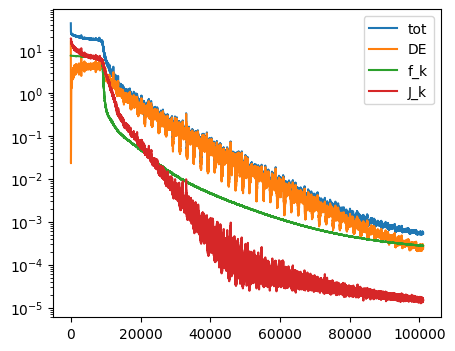

Min DE loss 0.00020696528372354805
Min f loss 0.0002755196692305617
Min J loss 1.2574984111779486e-05


In [270]:
# plot_loss_curves(loss_history=trainer.loss_history, case_name='gaussian_inclusion', noise_level_str='0pct')
loss = trainer.loss_history
w = trainer.config['loss_weights']

# for key in loss.keys():
#     print(key)

DE_loss = w['pde'] * np.array(loss['pde'])
f_bc_loss = w['data'] * np.array(loss['bc'])
J_bc_loss = w['data'] * np.array(loss['neumann'])
tot_loss = np.array(loss['total'])

fig = plt.figure(figsize=(5,4))
plt.plot(tot_loss, label = 'tot')
plt.plot(DE_loss, label = 'DE')
plt.plot(f_bc_loss, label = 'f_k')
plt.plot(J_bc_loss, label = 'J_k')

plt.yscale('log')
plt.legend()
plt.show()
fig.savefig(f'{saving_path}/all_losses_epoch_{len(DE_loss)}.pdf')

print('Min DE loss', min(DE_loss))
print('Min f loss', min(f_bc_loss))
print('Min J loss', min(J_bc_loss))


## Analysis

In [183]:
for key in data.keys():
    print(key)

gamma_true
boundary_coords
boundary_potentials
clean_currents
induced_potentials
grid_N
num_bcs


(512, 512)


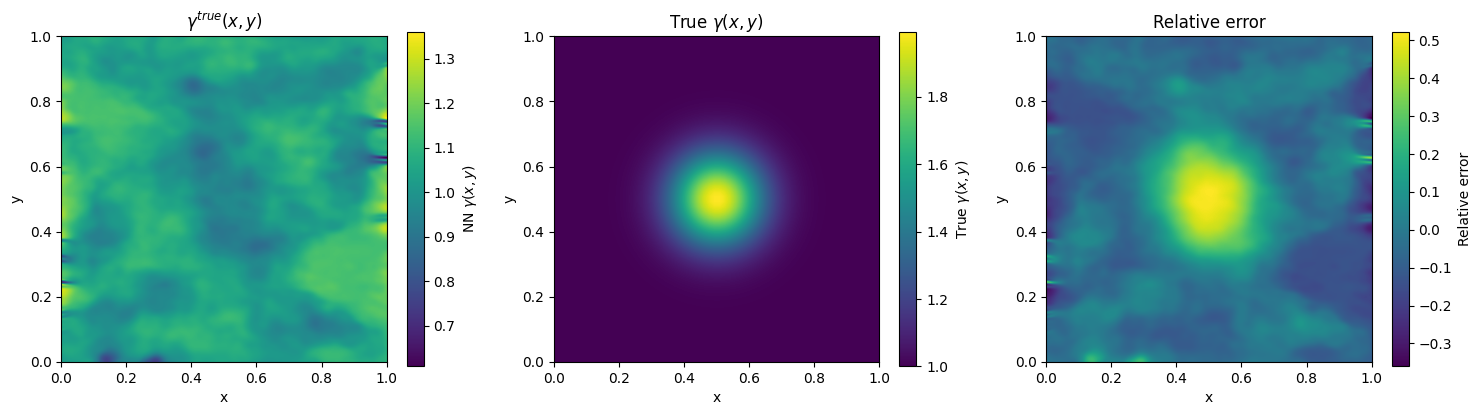

In [247]:
N = 512

gamma_nn = trainer.predict_gamma(N=N)

# 1D coordinates
x = torch.linspace(0, 1, N)
y = torch.linspace(0, 1, N)

# 2D meshgrid
X, Y = torch.meshgrid(x, y, indexing="ij")  # shape (N, N)

# Stack into (N*N, 2) list of coordinates
xy_grid = torch.stack([X.flatten(), Y.flatten()], dim=-1)
gamma_true = load_gamma_interpolator(data['gamma_true'])(xy_grid).reshape(N,N).cpu().detach().numpy()

eps = 1e-12
rel_error = (gamma_true - gamma_nn) / (gamma_true + eps)

print(gamma_nn.shape)

fig,ax = plt.subplots(1,3,figsize=(15,4))
im0 = ax[0].imshow(gamma_nn, origin='lower', extent=[0, 1, 0, 1], cmap="viridis")
fig.colorbar(im0, ax=ax[0], label=r"NN $\gamma(x,y)$")
ax[0].set_title(r"$\gamma^{true}(x,y)$")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")

im1 = ax[1].imshow(gamma_true, origin='lower', extent=[0, 1, 0, 1], cmap="viridis")
fig.colorbar(im1, ax=ax[1], label=r"True $\gamma(x,y)$")
ax[1].set_title(r"True $\gamma(x,y)$")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")

im2 = ax[2].imshow(rel_error, origin='lower', extent=[0, 1, 0, 1], cmap="viridis")
fig.colorbar(im2, ax=ax[2], label=r"Relative error")
ax[2].set_title("Relative error")
ax[2].set_xlabel("x")
ax[2].set_ylabel("y")

plt.tight_layout()
plt.show()
fig.savefig(f'{saving_path}/gamma_recovered_epoch_{len(DE_loss)}.pdf')

In [234]:
def plot_u_field(trainer, k_idx=0, N=200, plot_fig = True):
    """
    Plot the 2D field of the predicted potential u_net for a given boundary condition index.
    
    Args:
        trainer (Trainer): trained Trainer instance.
        k_idx (int): boundary condition index (0..K-1).
        N (int): grid resolution for the plot.
    """
    device = trainer.device
    ffe_encoder = trainer.ffe_encoder
    u_net = trainer.u_net
    num_bcs = trainer.num_bcs

    # Create uniform grid
    x = torch.linspace(0, 1, N, device=device)
    y = torch.linspace(0, 1, N, device=device)
    xx, yy = torch.meshgrid(x, y, indexing="ij")
    xy_grid = torch.stack([xx.flatten(), yy.flatten()], dim=1)  # [N*N, 2]

    # Fourier encode
    xy_ffe = ffe_encoder.encode(xy_grid)

    # One-hot for this boundary condition
    k_one_hot = torch.zeros(xy_grid.shape[0], num_bcs, device=device)
    k_one_hot[:, k_idx] = 1.0

    # Forward pass
    with torch.no_grad():
        u_pred = u_net(xy_ffe, k_one_hot)

    # Reshape to grid
    u_pred_img = u_pred.reshape(N, N).cpu().numpy()

    # Plot
    if plot_fig==True:
        fig = plt.figure(figsize=(5,5))
        # plt.figure(figsize=(6,5))
        plt.imshow(u_pred_img, extent=[0,1,0,1], origin="lower", cmap="plasma")
        plt.colorbar(label=r"$u_{NN}(x,y)$")
        plt.title(f"Induced u(x,y) for k={k_idx}")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.tight_layout()
        fig.savefig(f'{saving_path}/u_recovered_k_{k_idx}_epoch_{len(DE_loss)}.pdf')

        plt.show()
    
    return u_pred_img

# u_field = plot_u_field(trainer, k_idx=0, N=200)



In [ ]:
def plot_boundary_predictions(trainer, dataset, k_idx=0, use_gamma_th=False):
    """
    Plots the predicted potential u_nn, boundary potential f_all,
    and boundary currents J_all for a given boundary condition index.
    
    Args:
        trainer (Trainer): Trained Trainer instance.
        dataset (CalderonDataset): Dataset containing boundary data.
        k_idx (int): Index of the boundary condition to visualize.
    """
    device = trainer.device
    ffe_encoder = trainer.ffe_encoder
    gamma_net = trainer.gamma_net
    u_net = trainer.u_net
    
    # Select boundary coords & normals for this k
    xy_bnd = dataset.boundary_coords.to(device)  # [N_b, 2]
    bnd_coords = xy_bnd
    normals_bnd = dataset.normals.to(device)     # [N_b, 2]
    
    # True boundary values for this k
    f_true = dataset.boundary_potentials[k_idx].unsqueeze(1).to(device)  # [N_b, 1]
    J_true = dataset.currents[k_idx].unsqueeze(1).to(device)             # [N_b, 1]

    # Fourier feature encoding
    xy_bnd.requires_grad_(True)
    xy_ffe = ffe_encoder.encode(xy_bnd)

    # One-hot encoding for this boundary condition
    k_one_hot = torch.zeros(xy_bnd.shape[0], dataset.num_bcs, device=device)
    k_one_hot[:, k_idx] = 1.0

    # Forward pass through u_net
    u_pred = u_net(xy_ffe, k_one_hot)  # [N_b, 1]

    # Compute normal derivative ∂u/∂n
    grad_u = torch.autograd.grad(u_pred, xy_bnd, torch.ones_like(u_pred), create_graph=True)[0]
    du_dn_pred = torch.sum(grad_u * normals_bnd, dim=1, keepdim=True)

    # Predict conductivity γ(x) on the boundary
    if use_gamma_th==False:
        gamma_pred = gamma_net(xy_ffe)
    else:
        gamma_pred = trainer.gamma_true

    f_pred = u_pred

    # Predicted current
    J_pred = gamma_pred * du_dn_pred

    return bnd_coords, f_pred, J_pred



In [221]:
# bnd_coords, f_pred, J_pred = plot_boundary_predictions(trainer, dataset, k_idx=0)


# N = int(bnd_coords.shape[0]/4)
# K = int(trainer.num_bcs)

# print(N)
# k = 0

# ######### CHAT GPT ################

# x, y = bnd_coords[:,0].cpu().detach().numpy(), bnd_coords[:,1].cpu().detach().numpy()

# print(x.shape)

# # Identify edges
# tol = 1e-12
# bottom_idx = np.where(np.abs(y - 0.0) < tol)[0]
# top_idx    = np.where(np.abs(y - 1.0) < tol)[0]
# left_idx   = np.where(np.abs(x - 0.0) < tol)[0]
# right_idx  = np.where(np.abs(x - 1.0) < tol)[0]

# # Sort along each edge
# bottom_idx = bottom_idx[np.argsort(x[bottom_idx])]         # left→right
# top_idx    = top_idx[np.argsort(x[top_idx])][::-1]         # right→left
# right_idx  = right_idx[np.argsort(y[right_idx])]           # bottom→top
# left_idx   = left_idx[np.argsort(y[left_idx])][::-1]       # top→bottom

# # Concatenate perimeter
# perimeter_idx = np.concatenate([bottom_idx[:-1], right_idx[:-1], top_idx[:-1], left_idx[:-1]])

# # Reorder f and J consistently
# f_true = f_pred.cpu().detach().numpy()[perimeter_idx]
# print('f_true', f_true.shape)
# J_true = J_pred.cpu().detach().numpy()[perimeter_idx]

# afine = np.arange(4*(N))

# print('afine', afine.shape)

# #################

# fig,ax = plt.subplots(1,2, figsize=(10,4))
# ax[0].plot(afine, f_true, 'b-', label=r"$f_0$")
# ax[1].plot(afine, J_true, 'r-', label=r"$J_0$")
# for i in range(1,4):
#     ax[0].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
#     ax[1].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
# ax[0].set_xlabel('Perimeter')
# ax[1].set_xlabel('Perimeter')
# ax[0].set_ylabel('f(x,y)')
# ax[1].set_ylabel('J(x,y)')
# ax[0].set_xlim(left=0, right = 4*N-1)
# ax[1].set_xlim(left=0, right = 4*N-1)

# plt.suptitle('Bottom - Right - Top - Left Boundary')
# plt.show()

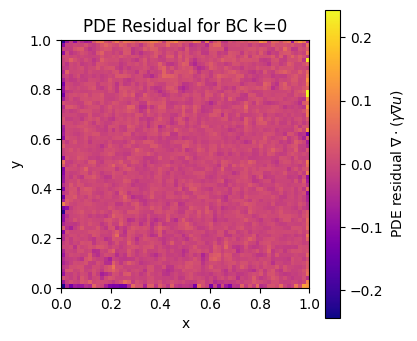

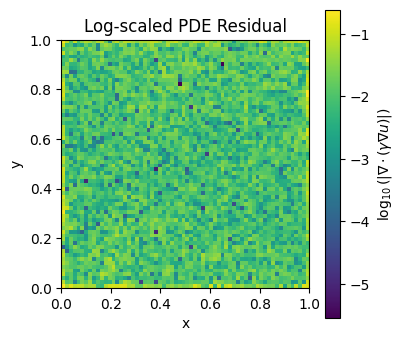

In [268]:
# --- choose which BC index to visualize ---
k_choice = 0   # for example, BC #0

# --- define grid points in [0, 1]² ---
N = 64
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
xx, yy = np.meshgrid(x, y)
xy = np.stack([xx.flatten(), yy.flatten()], axis=1)
xy_torch = torch.tensor(xy, dtype=torch.float32, device=trainer.pinn_manager.device)

# --- create the BC index tensor (same size as xy) ---
k_indices = torch.full((xy_torch.shape[0],), k_choice, dtype=torch.long, device=trainer.pinn_manager.device)

# with torch.no_grad():
residuals = trainer.pinn_manager.compute_pde_residual(xy_torch.clone().requires_grad_(True), k_indices)
residuals_np = residuals.cpu().detach().numpy().reshape(N, N)

fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(residuals_np, origin="lower", extent=[0,1,0,1], cmap="plasma", vmin=-np.abs(residuals_np).max(), vmax=np.abs(residuals_np).max())
plt.colorbar(im, ax=ax, label=r"PDE residual $\nabla \cdot (\gamma \nabla u)$")
ax.set_title(fr"PDE Residual for BC k={k_choice}")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

eps = 1e-8  # small offset to avoid log(0)
log_residuals = np.log10(np.abs(residuals_np) + eps)

fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(
    log_residuals,
    origin="lower",
    extent=[0, 1, 0, 1],
    cmap="viridis",
)
plt.colorbar(im, ax=ax, label=r"$\log_{10}(|\nabla \cdot (\gamma \nabla u)|)$")
ax.set_title(r"Log-scaled PDE Residual")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()


bnd coords shape torch.Size([252, 2])
N 63
per indx 252


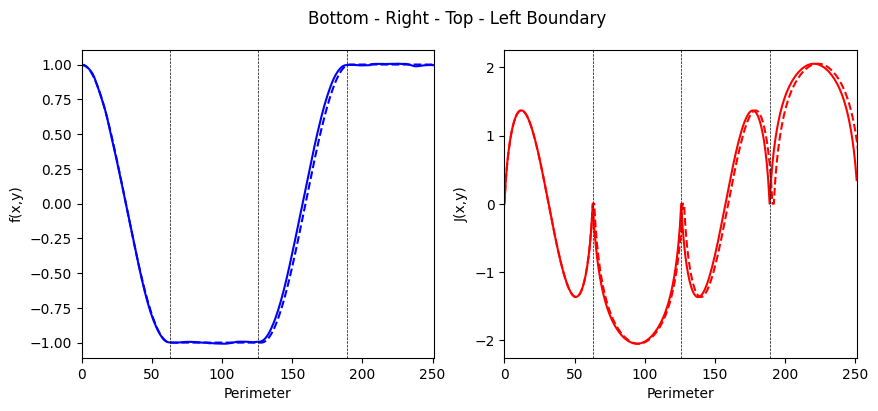

Numerical afine 256
NN afine 252


In [245]:
k = 0

############### Numerical Solution #################

data = np.load(data_filepath)
gamma_true = data["gamma_true"]          # (N, N) conductivity map
bnd_coords_true = data["boundary_coords"]     # (num_boundary_points, 2)
u_all_true = data["induced_potentials"]      # (K, N, N)
f_all_true = data["boundary_potentials"]      # (K, num_boundary_points)
J_all_true = data["clean_currents"]           # (K, num_boundary_points)
N_true = int(data["grid_N"])
# K = int(data["num_bcs"])

x_true, y_true = bnd_coords_true[:,0], bnd_coords_true[:,1]

tol_true = 1e-12
bottom_idx_true = np.where(np.abs(y_true - 0.0) < tol_true)[0]
top_idx_true    = np.where(np.abs(y_true - 1.0) < tol_true)[0]
left_idx_true   = np.where(np.abs(x_true - 0.0) < tol_true)[0]
right_idx_true  = np.where(np.abs(x_true - 1.0) < tol_true)[0]

bottom_idx_true = bottom_idx_true[np.argsort(x_true[bottom_idx_true])]         # left→right
top_idx_true    = top_idx_true[np.argsort(x_true[top_idx_true])][::-1]         # right→left
right_idx_true  = right_idx_true[np.argsort(y_true[right_idx_true])]           # bottom→top
left_idx_true   = left_idx_true[np.argsort(y_true[left_idx_true])][::-1]       # top→bottom

# print(right_idx_true)

perimeter_idx_true = np.concatenate([bottom_idx_true, right_idx_true, top_idx_true, left_idx_true])


f_true = f_all_true[k, perimeter_idx_true]
J_true = J_all_true[k, perimeter_idx_true]

afine_true = np.arange(4*(N_true))


###################### Predicted NN Solution #############

bnd_coords, f_pred, J_pred = plot_boundary_predictions(trainer, dataset, k_idx=k)

N = int(bnd_coords.shape[0]/4)
print('bnd coords shape', bnd_coords.shape)
print('N', N)
K = int(trainer.num_bcs)

x, y = bnd_coords[:,0].cpu().detach().numpy(), bnd_coords[:,1].cpu().detach().numpy()

tol = 1e-12
bottom_idx = np.where(np.abs(y - 0.0) < tol)[0]
top_idx    = np.where(np.abs(y - 1.0) < tol)[0]
left_idx   = np.where(np.abs(x - 0.0) < tol)[0]
right_idx  = np.where(np.abs(x - 1.0) < tol)[0]

bottom_idx = bottom_idx[np.argsort(x[bottom_idx])]         # left→right
top_idx    = top_idx[np.argsort(x[top_idx])][::-1]         # right→left
right_idx  = right_idx[np.argsort(y[right_idx])]           # bottom→top
left_idx   = left_idx[np.argsort(y[left_idx])][::-1]       # top→bottom

# print(right_idx)

perimeter_idx = np.concatenate([bottom_idx[:-1], right_idx[:-1], top_idx[:-1], left_idx[:-1]])
print('per indx', len(perimeter_idx))


f_nn = f_pred.cpu().detach().numpy()[perimeter_idx]
#print('f_true', f_true.shape)
J_nn = J_pred.cpu().detach().numpy()[perimeter_idx]
afine = np.arange(4*(N))

############ PLOT ############

fig,ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(afine, f_nn, 'b-', label=r"NN $f(x,y)$")
ax[0].plot(afine_true, f_true, 'b', linestyle = 'dashed', label=r"True $f(x,y)$")
ax[1].plot(afine, J_nn, 'r-', label=r"NN $J(x,y)$")
ax[1].plot(afine_true, J_true, 'r', linestyle = 'dashed', label=r"True $J(x,y)$")
for i in range(1,4):
    ax[0].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[1].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
ax[0].set_xlabel('Perimeter')
ax[1].set_xlabel('Perimeter')
ax[0].set_ylabel('f(x,y)')
ax[1].set_ylabel('J(x,y)')
ax[0].set_xlim(left=0, right = 4*N-1)
ax[1].set_xlim(left=0, right = 4*N-1)
plt.suptitle('Bottom - Right - Top - Left Boundary')
plt.show()

fig.savefig(f'{saving_path}/BC_f_and_J_recovered_k_{k}_epoch_{len(DE_loss)}.pdf')

print('Numerical afine', len(afine_true))
print('NN afine', len(afine))


u_all shape (1, 64, 64)


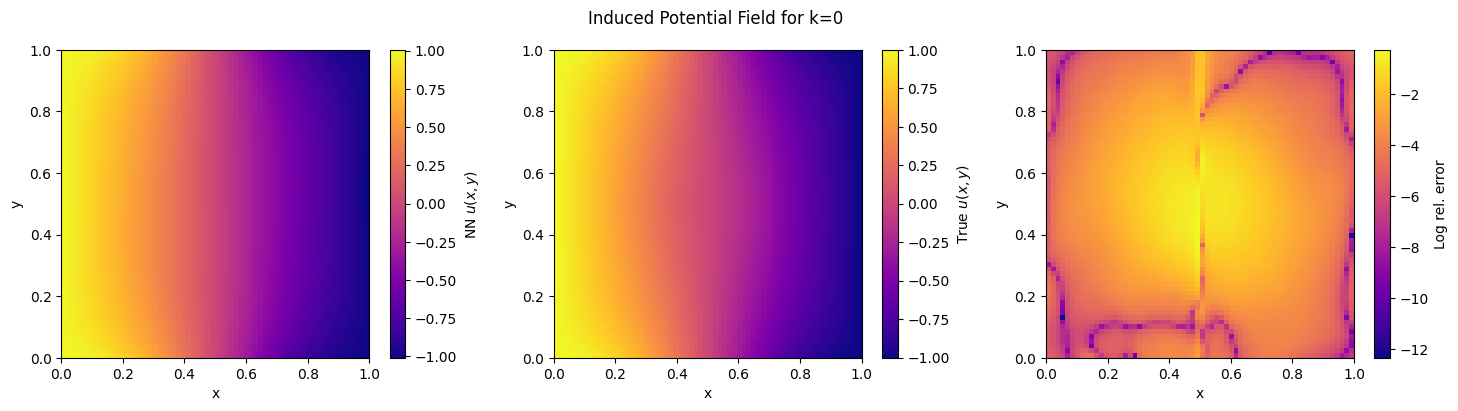

In [248]:
k=0

print('u_all shape', u_all_true.shape)

u_num = u_all_true[k,:,:]

u_nn = plot_u_field(trainer, k_idx=k, N=int(u_all_true.shape[-1]), plot_fig=False).T

rel_error_u = np.log(np.abs((u_num - u_nn)/u_num))

fig, ax = plt.subplots(1,3,figsize=(18,4))
im0 = ax[0].imshow(u_nn, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
fig.colorbar(im0, ax=ax[0], label=r"NN $u(x,y)$")
im1 = ax[1].imshow(u_num, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
fig.colorbar(im1, ax=ax[1], label=r"True $u(x,y)$")
im2 = ax[2].imshow(rel_error_u, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
fig.colorbar(im2, ax=ax[2], label=r"Log rel. error")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[2].set_xlabel("x")
ax[2].set_ylabel("y")
plt.suptitle(rf"Induced Potential Field for k={k}")
fig.savefig(f'{saving_path}/u_induced_k_{k}_compared_epoch_{len(DE_loss)}.pdf')
plt.show()

[0]
(252,)


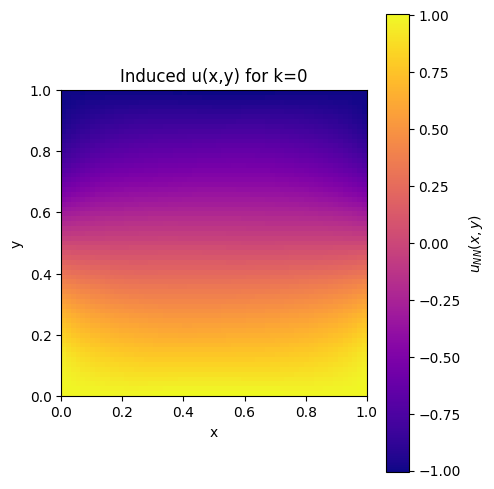

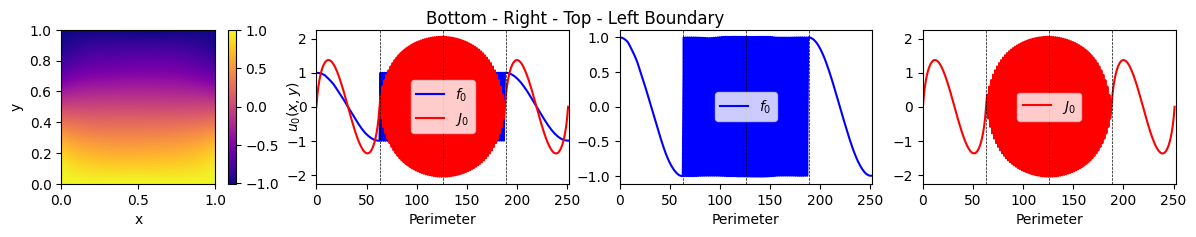

In [214]:
N = int(bnd_coords.shape[0]/4)
K = int(trainer.num_bcs)

k_list=np.arange(K)
print(k_list)

for k in (k_list):

    bnd_coords, f_pred, J_pred = plot_boundary_predictions(trainer, dataset, k_idx=k)
    x, y = bnd_coords[:,0].cpu().detach().numpy(), bnd_coords[:,1].cpu().detach().numpy()

    print(x.shape)

    # Identify edges
    tol = 1e-12
    bottom_idx = np.where(np.abs(y - 0.0) < tol)[0]
    top_idx    = np.where(np.abs(y - 1.0) < tol)[0]
    left_idx   = np.where(np.abs(x - 0.0) < tol)[0]
    right_idx  = np.where(np.abs(x - 1.0) < tol)[0]

    # Sort along each edge
    bottom_idx = bottom_idx[np.argsort(x[bottom_idx])]         # left→right
    top_idx    = top_idx[np.argsort(x[top_idx])][::-1]         # right→left
    right_idx  = right_idx[np.argsort(y[right_idx])]           # bottom→top
    left_idx   = left_idx[np.argsort(y[left_idx])][::-1]       # top→bottom

    # Concatenate perimeter
    perimeter_idx = np.concatenate([bottom_idx[:-1], right_idx[:-1], top_idx[:-1], left_idx[:-1]])
    afine = np.arange(4*(N))


    u_field = plot_u_field(trainer, k_idx=k, N=N)

    f_true = f_pred.cpu().detach().numpy() #f_all[k, perimeter_idx]
    J_true = J_pred.cpu().detach().numpy() #J_all[k, perimeter_idx]

    u_ex = u_field #u_all[k,:,:]

    fig,ax = plt.subplots(1,4,figsize=(15,2))

    im1 = ax[0].imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")
    fig.colorbar(im1, ax=ax[0], orientation='vertical', label = r'$u_0(x,y)$')

    ax[1].plot(afine, f_true, 'b-', label=r"$f_0$")
    ax[1].plot(afine, J_true, 'r-', label=r"$J_0$")
    for i in range(1,4):
        ax[1].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[1].set_xlabel('Perimeter')
    ax[1].legend()
    ax[1].set_xlim(left=0, right=4*N)

    ax[2].plot(afine, f_true, 'b-', label=r"$f_0$")
    for i in range(1,4):
        ax[2].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[2].set_xlabel('Perimeter')
    ax[2].legend()
    ax[2].set_xlim(left=0, right=4*N)

    ax[3].plot(afine, J_true, 'r-', label=r"$J_0$")
    for i in range(1,4):
        ax[3].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[3].set_xlabel('Perimeter')
    ax[3].legend()
    ax[3].set_xlim(left=0, right=4*N)
    
    plt.suptitle('Bottom - Right - Top - Left Boundary')

    plt.show()


In [126]:
4*31*5

620

In [163]:
# k=0

# i = 0
# for bnd_batch_cpu in dataloader:
#     print(i)
#     i += 1
#     # Move batch to device
#     bnd_batch = [t.to(trainer.device) for t in bnd_batch_cpu]
#     xy_bnd, k_bnd, normals_bnd, f_bnd, J_bnd = bnd_batch
#     print(xy_bnd.shape)
#     xy_mock = xy_bnd.reshape(4*31, 5,2)
#     print(xy_mock.shape)
#     k_mock = k_bnd.reshape(4*31, 5)
#     print('normals',normals_bnd.shape)
#     normals_mock = normals_bnd.reshape(4*31, 5,2)

#     k_one_hot = pinn_manager._to_one_hot(k_indices=k_mock[:,k], num_classes=trainer.num_bcs)

#     pde_batch = (xy_mock[:,k,:], k_one_hot)

# u_pred, J_pred = pinn_manager.compute_data_predictions(xy_mock[:,k,:], k_one_hot, normals_mock[:,k,:])

# k=0

# print('u_pred shape', u_pred.shape)

# u_ex = u_pred.cpu().detach().numpy()

# fig = plt.figure(figsize=(4,4))
# im1 = plt.imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
# plt.title(r"Induced Potential Field ")
# plt.xlabel("x")
# plt.ylabel("y")
# fig.colorbar(im1, label=r'$u_0(x,y)$', orientation='vertical')
# plt.show()

In [ ]:
k_list=np.arange(K)
print(k_list)

for k in (k_list):

    f_true = f_all[k, perimeter_idx]
    J_true = J_all[k, perimeter_idx]

    u_ex = u_all[k,:,:]

    fig,ax = plt.subplots(1,4,figsize=(15,2))

    im1 = ax[0].imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")
    fig.colorbar(im1, ax=ax[0], orientation='vertical', label = r'$u_0(x,y)$')

    ax[1].plot(afine, f_true, 'b-', label=r"$f_0$")
    ax[1].plot(afine, J_true, 'r-', label=r"$J_0$")
    for i in range(1,4):
        ax[1].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[1].set_xlabel('Perimeter')
    ax[1].legend()
    ax[1].set_xlim(left=0, right=4*N)

    ax[2].plot(afine, f_true, 'b-', label=r"$f_0$")
    for i in range(1,4):
        ax[2].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[2].set_xlabel('Perimeter')
    ax[2].legend()
    ax[2].set_xlim(left=0, right=4*N)

    ax[3].plot(afine, J_true, 'r-', label=r"$J_0$")
    for i in range(1,4):
        ax[3].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[3].set_xlabel('Perimeter')
    ax[3].legend()
    ax[3].set_xlim(left=0, right=4*N)
    
    plt.suptitle('Bottom - Right - Top - Left Boundary')

    plt.show()


In [ ]:
trainer.save_results(case, noise_str)

In [30]:
print(torch.backends.mps.is_available())  # True if GPU is available
print(torch.backends.mps.is_built()) 

True
True


In [35]:
main.trainer

AttributeError: 'function' object has no attribute 'trainer'

In [31]:
if __name__ == "__main__":
    # Fix: Set multiprocessing start method to 'spawn' for CUDA safety
    try:
        torch.multiprocessing.set_start_method('spawn', force=True)
    except RuntimeError:
        pass
    main()


RUNNING EXPERIMENT: CASE=gaussian_inclusion, NOISE=0pct

Using device: mps
Starting training for case: gaussian_inclusion, noise: 0pct


Training epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Training epochs: 100%|██████████| 100/100 [00:19<00:00,  5.12it/s]


Training finished. Total time: 19.53s
Saved final models, predictions, and loss history for gaussian_inclusion (0pct)
Loss curve plot saved to data/plot_loss_curves_gaussian_inclusion_0pct_1759334895.png
Plot description: Shows the evolution of total, PDE, data, and TV loss components during training.


NameError: name 'trainer' is not defined